# Rag From Scratch: Retrieval

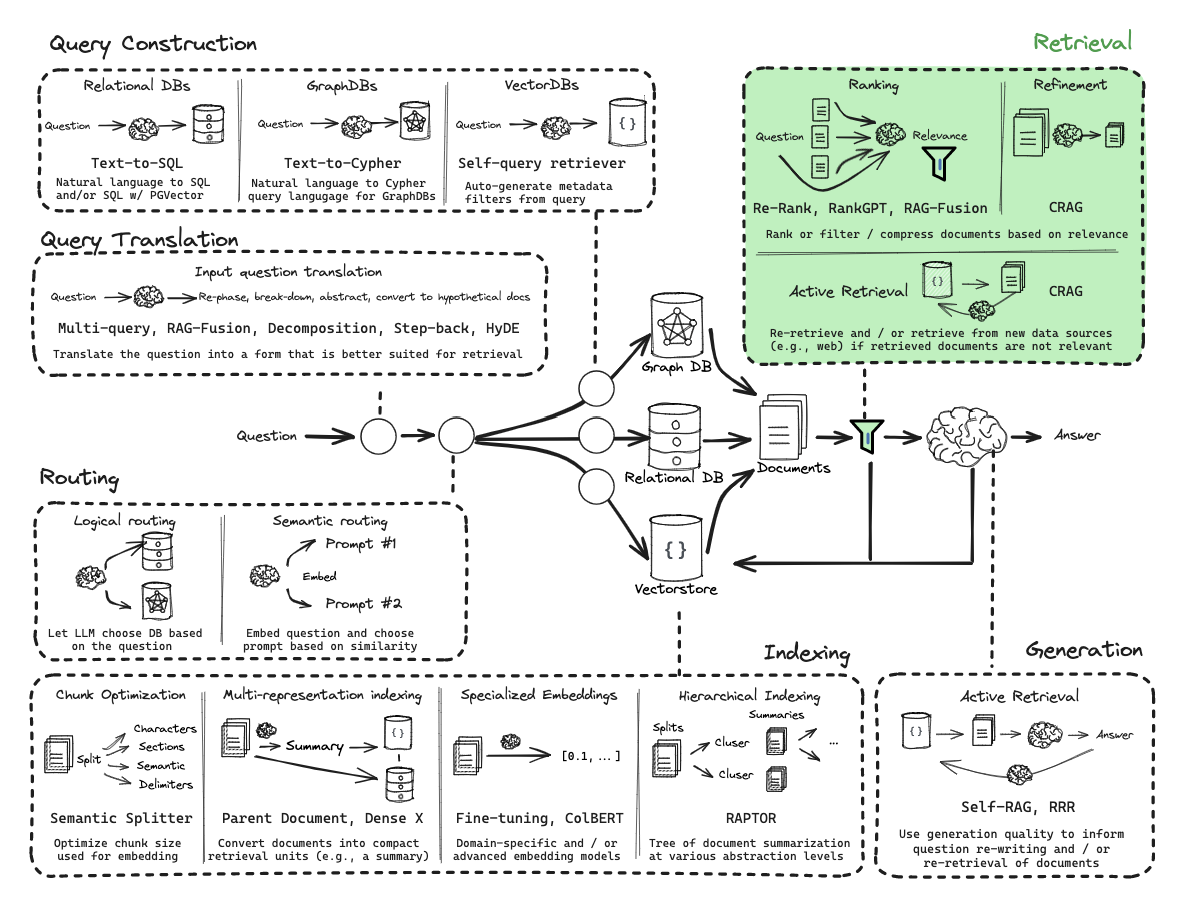

## Environment

`(1) Packages`

In [1]:
! pip install python-dotenv langchain-community langchain-text-splitters langchain-chroma langchain langchain-core langgraph pydantic langchain-tavily


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


`(2) LangSmith`

https://docs.smith.langchain.com/

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## Part 15: Re-ranking

We showed this previously with RAG-fusion.

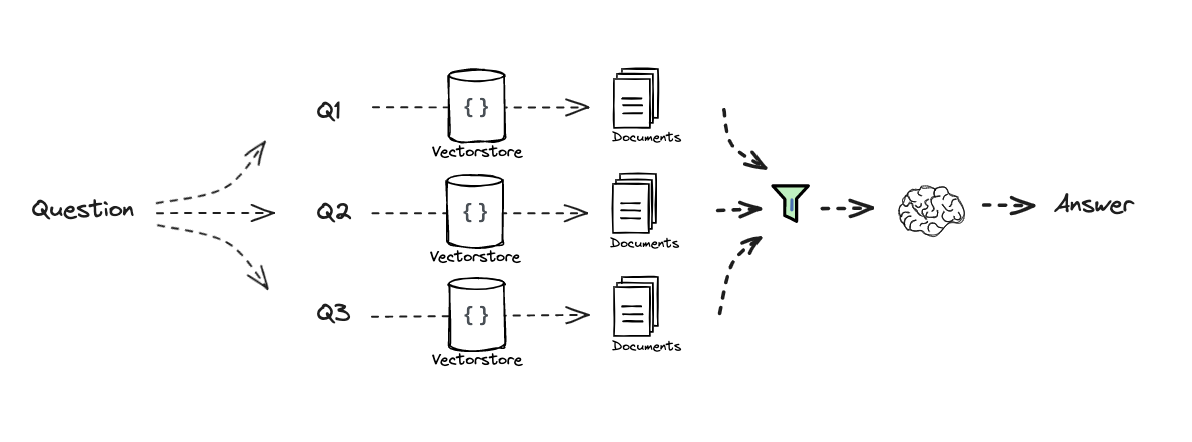

In [3]:
### INDEXING ###
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_ollama import ChatOllama, OllamaEmbeddings

# Load the blog document
loader = WebBaseLoader(
    web_path=('https://lilianweng.github.io/posts/2023-06-23-agent/'),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=('post-content', 'post-title', 'post-header')
        )
    )
)
blog_doc = loader.load()    # Document object

# Split the cocument
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = splitter.split_documents(blog_doc)

# Index
vectorstore = Chroma.from_documents(documents=splits, embedding=OllamaEmbeddings(model='nomic-embed-text'))
retriever = vectorstore.as_retriever()


c:\Users\SK\Desktop\Langchain_RAG_from_scratch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Template
template_rag_fusion = """You are a helpful assistant that generates multiple search queries based on a single input query.\n
Generate multiple search queries related to: {question}\n
Output (4 queries):
"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template_rag_fusion)

# Query generator chain
generate_queries = (
    prompt_rag_fusion
    | ChatOllama(model='qwen3:8b', temperature=0, reasoning=False)
    | StrOutputParser()
    | (lambda x: x.split('\n'))    # Split each generate query
)

In [5]:
### RAG-FUSION ###
from langchain_core.load import dumps, loads

# RAG-Fusion function
def reciprocal_rank_fusion(results: list[list], k=60):
    """
    Reciprocal_rank_fusion (RRF) that takes multiple lists of ranked documents
    and an optional parameter k used in the RRF formula
    * result: retrieved documents for each of multiple queries
    * k: smoothing constant to remove the dominant influence of top ranked documents on the final score
    """

    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a JSON string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)
    
    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score) for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]
    return reranked_results

In [6]:
# RAG-Fusion chain
chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion

# Get the re-ranked retrieved documents
question = "What is task decomposition for LLM agents?"
reranked_docs = chain_rag_fusion.invoke(question)
reranked_docs

C:\Users\SK\AppData\Local\Temp\ipykernel_40324\1136968245.py:29: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  (loads(doc), score) for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)


[(Document(id='c8172fa2-d104-4542-9bcc-d28374b2fa63', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.'),
  0.06639344262295081),
 (Document(id='2969392d-9b25-41cf-981b-1897044a9215', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#'),
  0.04918032786885246),
 (Document(id='9c97e7e2-19ca-4350-86fa-f186e44c6958', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to 

In [7]:
from langchain_core.runnables import RunnablePassthrough

# Final template
template_final = """Answer the follwoing quetions based on this context:

{context}

Question: {question}
"""
prompt_final = ChatPromptTemplate.from_template(template_final)

# Final run
final_chain_rag_fusion = (
    {'context': chain_rag_fusion, 'question': RunnablePassthrough()}
    | prompt_final
    | ChatOllama(model='qwen3:8b', temperature=0, reasoning=False)
    | StrOutputParser()
)
final_chain_rag_fusion.invoke(question)

'Task decomposition for LLM agents involves breaking down complex tasks into smaller, manageable subgoals or steps. This allows the agent to handle the task more efficiently by focusing on one part at a time. Task decomposition can be achieved through various methods, such as using simple prompting, task-specific instructions, or incorporating human input. It is a crucial component in enabling LLM agents to perform complicated tasks effectively.'

We can also use [Cohere Re-Rank](https://python.langchain.com/docs/integrations/retrievers/cohere-reranker#doing-reranking-with-coherererank). 

See [here](https://txt.cohere.com/rerank/): Rerank endpoint, which acts as the last stage of a search flow to provide a ranking of relevant documents per a user’s query. This means that companies can retain an existing keyword-based (also called “lexical”) or semantic search system for the first-stage retrieval and integrate the Rerank endpoint in the second stage re-ranking.

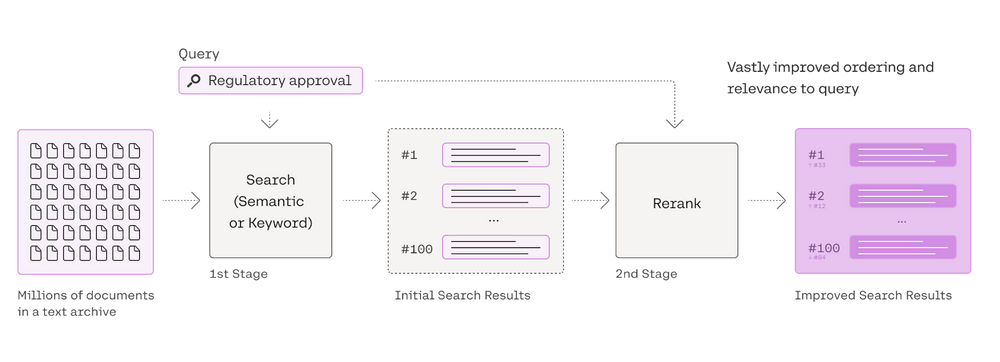

To use the Cohere Rerank as coded below, install langchain-cohere and set Cohere API key first.

In [8]:
# from langchain_cohere import CohereRerank
# from langchain.retrievers.contextual_compression import ContextualCompressionRetriever

# # Initialize the base retriever
# base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# # Initialize Cohere reranker
# cohere_reranker = CohereRerank(model="rerank-english-v3.0")

# # Create contextual compression retriever with Cohere reranker
# compression_retriever = ContextualCompressionRetriever(
#     base_compressor=cohere_reranker,
#     base_retriever=base_retriever
# )

# # Get reranked documents
# reranked_docs_cohere = compression_retriever.get_relevant_documents(question)
# reranked_docs_cohere

## Part 16: Corrective RAG (CRAG)

`Deep Dive`

https://www.youtube.com/watch?v=E2shqsYwxck

`Notebooks`

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_crag.ipynb

Corrective-RAG (CRAG) is a strategy for RAG that incorporates self-reflection / self-grading on retrieved documents. 

In the paper [here](https://arxiv.org/pdf/2401.15884.pdf), a few steps are taken:

* If at least one document exceeds the threshold for relevance, then it proceeds to generation.
* Before generation, it performs knowledge refinement.
* This partitions the document into "knowledge strips".
* It grades each strip, and filters our irrelevant ones.
* If all documents fall below the relevance threshold or if the grader is unsure, then the framework seeks an additional datasource.
* It will use web search to supplement retrieval.
 
We will implement some of these ideas from scratch using [LangGraph](https://langchain-ai.github.io/langgraph/):

* Let's skip the knowledge refinement phase as a first pass. This can be added back as a node, if desired. 
* If *any* documents are irrelevant, let's opt to supplement retrieval with web search. 
* We'll use [Tavily Search](https://python.langchain.com/v0.2/docs/integrations/tools/tavily_search/) for web search.
* Let's use query re-writing to optimize the query for web search.

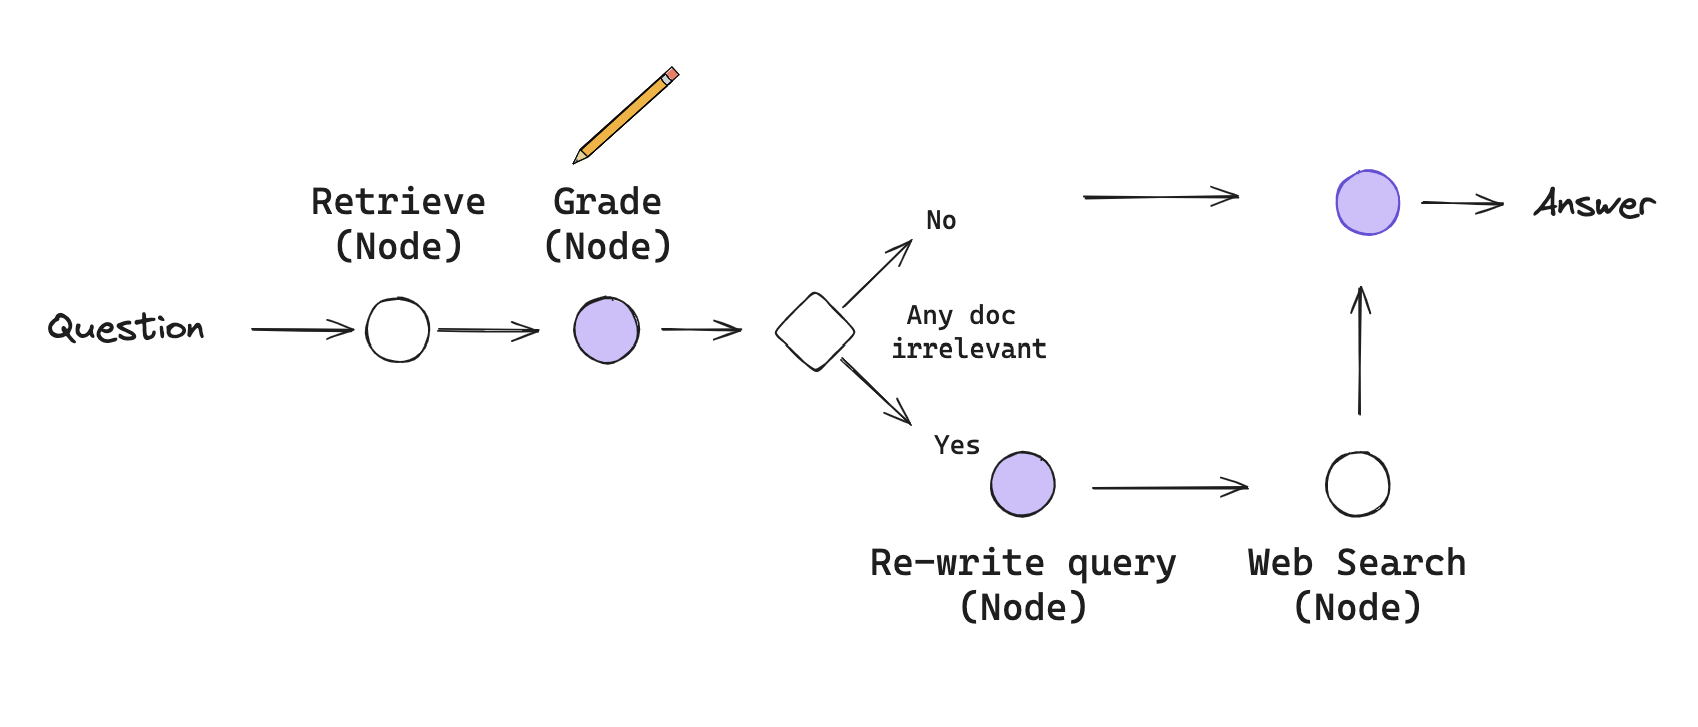

In [9]:
import getpass

# To type in API keys when they are not set
def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f'Value for {key}:')

_set_env('TAVILY_API_KEY')

## Build Chains

### Create Index

The first `Retrieve` node

In [10]:
# Load
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/',
]

docs = [WebBaseLoader(url).load() for url in urls]      # [[Document01], [Document02], ...]
doc_list = [doc for sublist in docs for doc in sublist]    # Flatten to: [Document01, Document02, ...]

# Split
splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=0)
splits = splitter.split_documents(doc_list)

# Index
vectorstore = Chroma.from_documents(
    documents=splits, 
    collection_name='crag-chroma', 
    embedding=OllamaEmbeddings(model='nomic-embed-text')
)
retriever = vectorstore.as_retriever()

### LLM with Grader

The second `Grade` node

In [11]:
### RETRIEVEL GRADER ###
from pydantic import BaseModel, Field
from typing import Literal

# Prompt
system_msg = '''You are a grader assessing relevance of a retrieved document to a user question.\n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.\n
    Give a binary score "yes" or "no" score to indicate whether the document is relevant to the question.'''

grader_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_msg),
        ('human', 'Retrieved document:\n\n{document}\n\nUser question: {question}')
    ]
)

# Grader function call
class GradeDocuments(BaseModel):
    """ Binary score (yes/no) for relevance check on retrieved documents """
    # Not assign the first default parameter -> same as required(...)
    binary_score: Literal['yes', 'no'] = Field(
        description='Whether the document is relevent to the question; "yes" or "no"'
    )

# LLM with function call
llm = ChatOllama(model='qwen3:8b', temperature=0, reasoning=False)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Chain
retrieval_grader = (
    grader_prompt 
    | structured_llm_grader    # No need of parser
)

# Run: For later use, pick only one document to use as context
question = 'Agent memory'
docs = retriever.invoke(question)
doc_text = docs[2].page_content
retrieval_grader.invoke({'document': doc_text, 'question': question})

GradeDocuments(binary_score='yes')

### Question Re-writer

The third `Re-write Query` node

In [12]:
# Prompt
system_msg = '''You a question re-writer that converts an input question to a better version that is optimized \n 
for web search. Look at the input and try to reason about the underlying semantic intent / meaning.'''

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_msg),
        ('human', 
         'Here is the initial question:\n\n{question}\n\nFormulate an improved question (only question):'
        )
    ]
)

# Rewrite chain
question_rewriter = rewrite_prompt | llm | StrOutputParser()
question_rewriter.invoke(question)

'What is agent memory and how does it function in artificial intelligence systems?'

### Web Search Tool

The fourth `Web Search` node

In [13]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3)
web_search_tool.invoke({'query': question})

{'query': 'Agent memory',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/ai-agent-memory',
   'title': 'What Is AI Agent Memory? | IBM',
   'content': 'AI agent memory refers to an [artificial intelligence](https://www.ibm.com/think/topics/artificial-intelligence)\xa0(AI) system’s ability to store and recall past experiences to improve decision-making, perception and overall performance. [AI agents](https://www.ibm.com/think/topics/ai-agents) do not necessarily need memory systems. AI agents typically implement semantic memory using knowledge bases, symbolic AI or [vector embeddings](https://www.ibm.com/think/topics/vector-embedding), allowing them to process and retrieve relevant information efficiently. One key [agent framework](https://www.ibm.com/think/insights/top-ai-agent-frameworks) for building memory-enabled AI agents is [LangChain](https://www.ibm.com/think/topics/langchain), which facilitates the integrati

## Create Graph

Now let's create out graph that will use CRAG.

### Define Graph State

In [14]:
from typing import List                   # Type hint
from typing_extensions import TypedDict   # New type definition
from langchain_core.documents import Document

# TypeDict: Define key and value types in a dictionary. It's only for type hinting and does not enforce the structure at runtime.
class GraphState(TypedDict):    # Define GraphState as type TypeDict
    ''' 
    Represents the state of our graph.
    
    Args:
        question: question
        documents: list of documents
        generation: LLM generation
        web_search: whether to add search or not
    '''
    question: str
    documents: List[Document]
    generation: str
    web_search: str


### Define Functions to Update Graph State
> `Nodes` should return the updated GraphState.

In [15]:
### NODES ###
from langchain_classic import hub

# 1. Retrieve
def retrieve(state):
    '''
    Retrieve documents.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key 'documents' added to state, that contains retrieved documents
    '''
    print('===RETRIEVE===')
    question = state['question']

    # Retrieval
    documents = retriever.invoke(question)
    return {'question': question, 'documents': documents}

# 2. Grade each document
def grade_documents(state):
    ''' 
    Determines whether the retrieved documents are relevant to the question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates 'documents' key with only filtered relevant documents
    '''
    print('===CHECK DOCUMENT RELEVANCE TO QUESTION===')
    question = state['question']
    documents = state['documents']

    relevant_docs = []
    web_search = 'NO'

    for doc in documents:
        score = retrieval_grader.invoke({'document':doc.page_content, 'question': question})
        # score: class GradeDocuments(binary_score='...') 
        grade = score.binary_score
        if grade == 'yes':
            print('===GRADE: DOCUMENT RELEVANT===')
            relevant_docs.append(doc)
        else:
            print('===GRADE: DOCUMENT NOT RELEVANT===')
            web_search = 'YES'

    return {'question': question, 'documents': relevant_docs, 'web_search': web_search}   

# 3. RAG generation - without web search
def generate(state):
    ''' 
    Generate an answer.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key 'generation' added to state, that contains LLM generation
    '''
    print('===GENERATE===')
    question = state['question']
    documents = state['documents']

    prompt = hub.pull('rlm/rag-prompt')
    rag_chain = prompt | llm | StrOutputParser()
    generation = rag_chain.invoke({'context': documents, 'question': question})
    return {'question': question, 'documents': documents, 'generation': generation}     

# 4. Re-write query
def transform_query(state):
    ''' 
    Transform the query to produce a better question for search.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates 'question' key with a rephrased question
    '''
    print('===TRANSFORM QUERY===')
    question = state['question']
    documents = state['documents']

    rephrased_question = question_rewriter.invoke(question)
    return {'question': rephrased_question, 'documents': documents}

# 5. Web search
def web_search(state):
    ''' 
    Web search based on the re-written question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates 'documents' key with appended web results
    '''
    print('===WEB SEARCH===')
    question = state['question']
    documents = state['documents']

    search_result = web_search_tool.invoke(question)
    result = '\n'.join(dic['content'] for dic in search_result['results'])
    result = Document(page_content=result)
    documents.append(result)

    return {'question': question, 'documents': documents}

> `Edges` should return the next node.

In [16]:
### BRANCHING EDGES ###
def decide_to_generate(state):
    ''' 
    Determines whether to generate an answer or re-write a question.
    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for next node to call
    '''
    print('===ASSESS GRADED DOCUMENTS===')
    web_search = state['web_search']

    if web_search == 'YES':
        print('===DECISION: AT LEAST ONE DOCUMENT IS NOT RELEVANT TO THE QUESTION, SO REWRITE QUERY===')
        return 'transform_query'
    else:
        print('===DECISION: GENERATE ANSWER===')
        return 'generate'

## Compile Graph

Follow the flow we outlined in the previous figure.

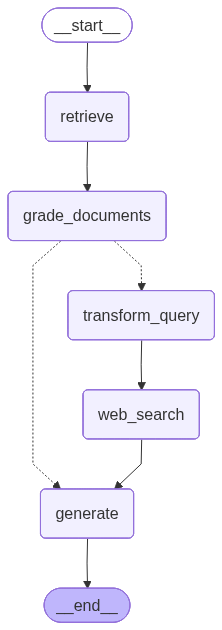

In [17]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node('retrieve', retrieve)
workflow.add_node('grade_documents', grade_documents)
workflow.add_node('generate', generate)
workflow.add_node('transform_query', transform_query)
workflow.add_node('web_search', web_search)

# Build graph by connecting nodes
workflow.add_edge(START, 'retrieve')
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents', 
    decide_to_generate,
    {
        'generate': 'generate',
        'transform_query': 'transform_query'

    }
)
workflow.add_edge('transform_query', 'web_search')
workflow.add_edge('web_search', 'generate')
workflow.add_edge('generate', END)

# Compile
app = workflow.compile()
app


## Use Graph

In [ ]:
from pprint import pprint

# Run 1
input = {'question': 'What are the types of agent memory?'}
for output in app.stream(input):   # output: dict {node: returned value}
    for key, value in output.items():
        pprint(f'"{key}" Node:')
        pprint(value, indent=2, width=80, depth=None)
    pprint('\n-----------------------------------------------\n')

# Final answer
pprint(value['generation'])

===RETRIEVE===
'"retrieve" Node:'
{ 'documents': [ Document(id='e04d8a7c-e9a9-4003-82be-54acfa8cf20b', metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort

In [19]:
# Run 2
input = {'question': 'How does the AlphaCodium paper work?'}
for output in app.stream(input):
    for key, value in output.items():
        pprint(f'"{key}" Node:')
        pprint(value, indent=2, width=80, depth=None)
    print('\n-----------------------------------------------\n')

# Final answer
pprint(value['generation'])

===RETRIEVE===
'"retrieve" Node:'
{ 'documents': [ Document(id='e552b0fb-9887-476f-98fb-14307bb12f48', metadata={'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improvin

# Rag From Scratch: Generation

## Part 17: Self-RAG (Self-reflective RAG)
 
`Notebooks`

https://github.com/langchain-ai/langgraph/tree/main/examples/rag

Self-RAG is a strategy for RAG that incorporates self-reflection / self-grading on retrieved documents and generations. It could have latency issue, which can be mitigated by (1) using fast LLM for grading, or (2) restricting the cyclic iteration to one turn.

In the [paper](https://arxiv.org/abs/2310.11511), the framework trains an LLM to generate self-reflection tokens that govern various stages in the RAG process. Here is a summary of the tokens:

1. Should I retrieve from retriever, `R`

* Input: `x (question)` OR `x (question)`, `y (generation)`
* Decides when to retrieve `D` chunks with `R`
* Output: `yes, no, continue`

2. Are the retrieved passages `D` relevant to the question `x`

* Input: (`x (question)`, `d (chunk, in D)`) for `d` in `D`
* `d` provides useful information to solve `x`
* Output: `relevant, irrelevant`

3. Are the LLM generation from each chunk in `D` is relevant to the chunk (hallucinations, etc)  -

* Input: `x (question)`, `d (chunk)`,  `y (generation)` for `d` in `D`
* All of the verification-worthy statements in `y (generation)` are supported by `d`
* Output: `{fully supported, partially supported, no support`

4. The LLM generation from each chunk in `D` is a useful response to `x (question)`

* Input: `x (question)`, `y (generation)` for `d` in `D`
* `y (generation)` is a useful response to `x (question)`.
* Output: `{5, 4, 3, 2, 1}`

We will implement some of these ideas from scratch using [LangGraph](https://langchain-ai.github.io/langgraph/).

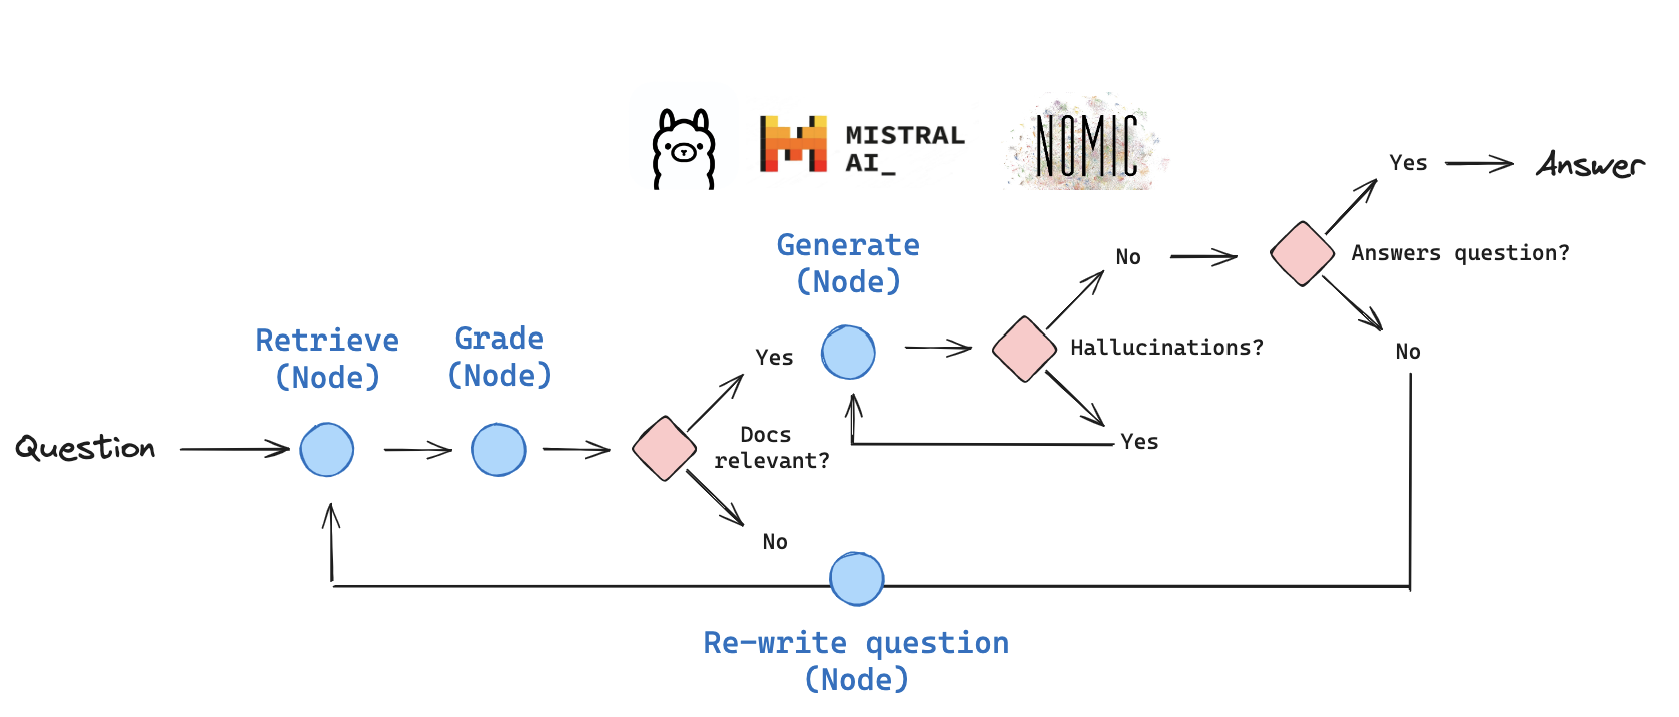

## Build Chains

### Create Index

In [20]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]    # List of list
doc_list = [doc for sublist in docs for doc in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=0)
doc_splits = text_splitter.split_documents(doc_list)

vectorstore = Chroma.from_documents(
    documents=doc_splits, 
    collection_name='self-rag-chroma',
    embedding=OllamaEmbeddings(model='nomic-embed-text')
)
retriever = vectorstore.as_retriever()

### Retrieval Grader

In [21]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

prompt = PromptTemplate(
    input_variables=['document', 'question'],
    template='''You are a grader assessing relevance of a retrieved document to a user question. \n 
    Here is the retrieved document: \n\n {document} \n\n
    Here is the user question: {question} \n
    If the document contains context related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question. \n
    Provide only the binary score as a JSON with a single key 'score' and no premable or explanation.'''
)

llm = ChatOllama(model='qwen3:8b', temperature=0, reasoning=False)

retrieval_grader = prompt | llm | JsonOutputParser()    # To get structured output in JSON object

question = 'Agent memory'
retrieved_docs = retriever.invoke(question)
doc_text = retrieved_docs[3].page_content
retrieval_grader.invoke({'document': doc_text, 'question': question})

{'score': 'yes'}

### Generation

In [22]:
prompt = hub.pull('rlm/rag-prompt')

def format_docs(docs: list[Document]) -> str:
    return '\n\n'.join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({'context': format_docs(retrieved_docs), 'question': question})
generation

'Agent memory refers to the capacity of an agent to retain and use past experiences and information. It encompasses various types of memory, such as sensory, short-term, and explicit memory. This enables agents to learn, make decisions, and adapt to new situations.'

### Hallucination Grader

In [25]:
prompt = PromptTemplate(
    input_variables=['documents', 'generation'],
    template='''You are a grader assessing whether an answer is grounded in / supported by a set of facts in the documents.\n 
    Here are the facts:
    \n ------- \n
    {documents} 
    \n ------- \n
    Here is the answer: {generation}
    Give a binary score 'yes' or 'no' score to indicate whether the answer is grounded in / supported by a set of facts.\n
    Provide the binary score as a JSON with a single key 'score' and no preamble or explanation.'''
)

hallucination_grader = prompt | llm | JsonOutputParser()
hallucination_grader.invoke({'documents': format_docs(retrieved_docs), 'generation': generation})

{'score': 'yes'}

### Answer Grader

In [30]:
prompt = PromptTemplate(
    input_variables=['question', 'generation'],
    template='''You are a grader assessing whether an answer is useful to resolve a question.\n 
    Here is the question: {question}
    Here is the answer:
    \n ------- \n
    {generation} 
    \n ------- \n
    Give a binary score 'yes' or 'no' to indicate whether the answer is useful to resolve a question.\n
    Provide the binary score as a JSON with a single key 'score' and no preamble or explanation.'''
)

answer_grader = prompt | llm | JsonOutputParser()
answer_grader.invoke({'question': question, 'generation': generation})

{'score': 'yes'}

### Question Re-writer

In [32]:
system_msg = '''You a question re-writer that converts an input question to a better version that is optimized \n 
    for web search. Look at the input and try to reason about the underlying semantic intent / meaning.'''
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_msg),
        ('human', 'Here is the initial question:\n\n{question}\n\nFormulate an improved question and return only the improved question.')
    ]
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()
question_rewriter.invoke(question)

'What is agent memory and how does it function in artificial intelligence systems?'

## Graph State

In [37]:
class GraphSate(TypedDict):
    '''
    Represents the state of the graph.

    Args:
        question: question
        documents: list of documnets
        generation: LLM genration
    '''
    question: str
    documents: List[Document]
    generation: str

## Define Graph Functions
### Nodes: returns the GraphState.

In [38]:
def retrieve(state):
    ''' 
    Retrieve documents

    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New 'documents' key added to state, that contains retrieved documents
    '''
    print('===RETRIEVE===')
    question = state['question']

    documents = retriever.invoke(question)
    return {'question': question, 'documents': documents}

def grade_filter_documents(state):
    ''' 
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    '''
    print('===CHECK DOCUMENT RELEVANCE TO QUESTION===')
    question = state['question']
    documents = state['documents']

    relevant_docs = []
    for doc in documents:
        score = retrieval_grader.invoke({'document': doc.page_content, 'question':question})
        grade = score['score']
        if grade == 'yes':
            print('===GRADE: DOCUMENT RELEVANT===')
            relevant_docs.append(doc)
        else:
            print('===GRADE: DOCUMENT NOT RELEVANT===')
    return {'question': question, 'documents': relevant_docs}

def generate(state):
    '''
    Generate answer

    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New 'generation' key added to state, that contains LLM generation 
    '''
    print('===GENERATE===')
    question = state['question']
    documents = state['documents']

    generation = rag_chain.invoke({'context': format_docs(documents), 'question': question})
    return {'question': question, 'documents': documents, 'generation': generation}

def transform_query(state):
    '''
     Transform the query to produce a better question.

    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates 'question' key with a re-phrased question
    '''
    print('===TRANSFORM QUERY===')
    question = state['question']

    rewritten_question = question_rewriter.invoke({'question': question})
    return {'question': rewritten_question}

### Edges: returns the next node or path.

In [39]:
def decide_to_generate(state):
    ''' 
    Determines whether to generate an answer, or re-write a question.

    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for next node to call
    '''
    print('===ASSESS GRADED DOCUMENTS===')
    relevant_docs = state['documents']

    if not relevant_docs:
        print('===DECISION:NO RELEVANT DOCUMENT, SO REWRITE QUERY===')
        return 'transform_query'
    else:
        print('===DECISION: GENERATE ANSWER===')
        return 'generate'
    
def grade_generation_hallucination_usefulness(state):
    ''' 
    Determines whether the generation is grounded in the document and answers the question.

    Args:
        state (dict): The current graph state
    Returns:
        str: Decision for next node to call
    '''
    print('===CHECK HALLUCINATION AGAINST DOCUMENTS===')
    question = state['question']
    documents = state['documents']
    generation = state['generation']

    grounded_score = hallucination_grader.invoke({'documents': format_docs(documents), 'generation': generation})
    grounded_grade = grounded_score['score']

    if grounded_grade == 'yes':
        print('===DECISION: GENERATION IS GROUNDED IN THE DOCUMENTS===')
        print('===CHECK USEFULNESS AGAINST QUESTION ===')
        useful_score = answer_grader.invoke({'question': question, 'generation': generation})
        useful_grade = useful_score['score']
        if useful_grade == 'yes':
            print('===DECISION: GENERATION ANSWERS THE QUESTION===')
            return 'useful'
        else:
            print('===DECISION: GENERATION DOES NOT ANSWER THE QUESTION===')
            return 'not_useful'
    else: 
        print('===DECISION: GENERATION IS NOT GROUNDED IN THE DOCUMENTS, SO RE-GENERATE===')
        return 'not grounded'


## Build Graph

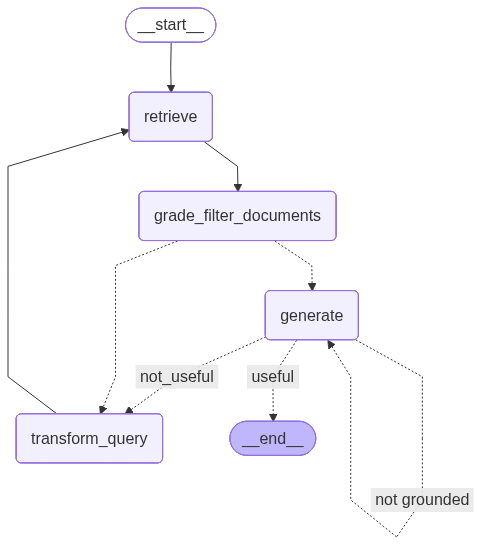

In [44]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node('retrieve', retrieve)
workflow.add_node('grade_filter_documents', grade_filter_documents)
workflow.add_node('generate', generate)
workflow.add_node('transform_query', transform_query)

# Build graph
workflow.add_edge(START, 'retrieve')
workflow.add_edge('retrieve', 'grade_filter_documents')
workflow.add_conditional_edges(
    'grade_filter_documents',
    decide_to_generate,
    {
        'generate': 'generate',
        'transform_query': 'transform_query'
    }
)
workflow.add_conditional_edges(
    'generate',
    grade_generation_hallucination_usefulness,
    {
        'useful': END,
        'not_useful': 'transform_query',
        'not grounded': 'generate'
    }

)
workflow.add_edge('transform_query', 'retrieve')

workflow.compile()

## Run Graph

In [54]:
input = {'question': 'Explain how the different types of agent memory work?'}

for output in app.stream(input):   # output: dict {node: returned value}
    for node, returns in output.items():
        pprint(f'"{node}" NODE')
        pprint(returns, indent=2, width=100, depth=None)
        print('\n-----------------------------------------------\n')

# Final generation
pprint(returns['generation'])

===RETRIEVE===
'"retrieve" NODE'
{ 'documents': [ Document(id='16d14190-1956-4cc9-8625-c7832e024ce3', metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-

## Part 18: Adaptive RAG

Adaptive RAG is a strategy for RAG that unites (1) `query analysis (& routing)` with (2) `self-corrective RAG`.
Good to read about unit test [here](https://hamel.dev/blog/posts/evals) and bring the idea into RAG.

`Command-R` by Cohere can be one of the options for routing destination along with vectorstore and web search.
* Routing
    * Built in query re-writing
    * Tool use
* Grading
    * Small (35b parameters)
    * Fast
* RAG
    * 128k context
  
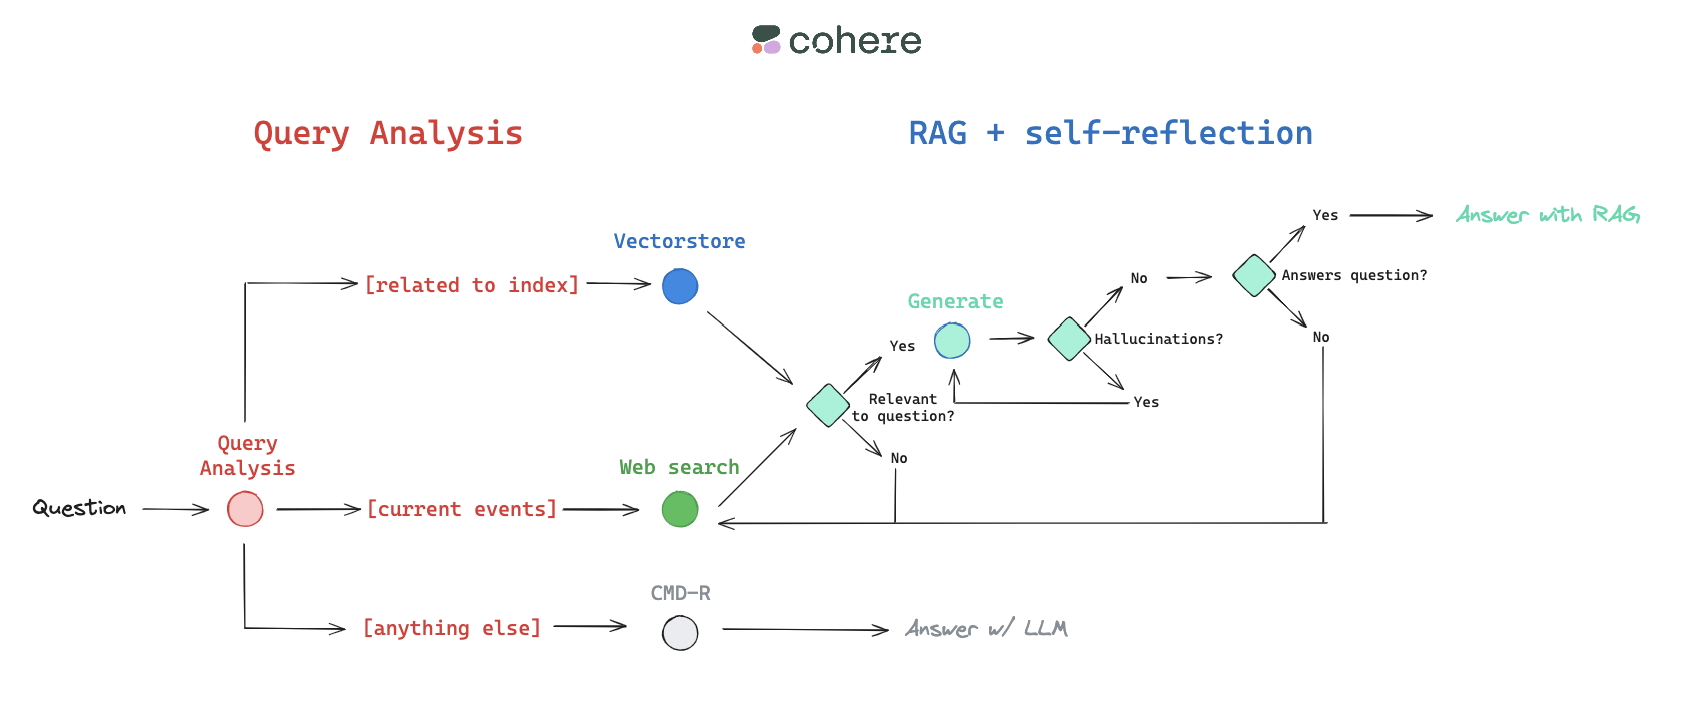

`Notebook`

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_adaptive_rag_cohere.ipynb

## Part 19: Impact of Long Context Window

`Deep dive`

https://www.youtube.com/watch?v=SsHUNfhF32s

`Slides`

https://docs.google.com/presentation/d/1mJUiPBdtf58NfuSEQ7pVSEQ2Oqmek7F1i4gBwR6JDss/edit#slide=id.g26c0cb8dc66_0_0